# Controlled Depth-Varying Manning's n for HEC-RAS 2D Linux Solves

> **EXPERIMENTAL — not recommended for production or any other
> non-experimental use.** The direct temporary-HDF methods in this notebook
> have been tested only with HEC-RAS 7.0 April 2026 in this exact
> Windows-preprocess/Linux-solve workflow. All other HEC-RAS versions and
> workflows are untested.

Manning's roughness coefficient varies with flow depth — this is well-established
in hydraulic literature (Chow 1959, HEC-15, Limerinos 1970, Jarrett 1984) and is
a frequent topic in HEC-RAS community discussions because many 2D models still
start from uniform roughness values.

This notebook demonstrates a complete `ras-commander` workflow for applying
**depth-varying Manning's n** to HEC-RAS 2D face property tables:

1. **Literature grounding** — formulas that relate n to hydraulic radius
2. **Model context** — terrain, 1D/2D geometry, lateral coupling, and boundary conditions
3. **Three controlled scenarios** — baseline, extension-only control, and depth-varying n
4. **Windows preprocessing** — generate solver-ready `.tmp.hdf` face tables
5. **Guarded `.tmp.hdf` edits** — extend identical tables, then vary only n in the modified case
6. **Linux RasUnsteady execution** — run the native HEC-RAS 7.0 solver without regenerating tables
7. **Isolated hydraulic review** — compare modified minus extension-only-control WSE
8. **Polygon mask API** — demonstrate selective channel-only application

**Key insight**: HEC-RAS 2D face property tables store Manning's n as a function
of elevation for each cell face. By modifying and extending the preprocessed
`.tmp.hdf` tables with a depth-varying formula, the Linux solver can consume the
edited tables directly rather than rebuilding them from the geometry settings.

**API methods demonstrated**:

| Method | Purpose |
|--------|---------|
| `GeomStorage.get_2d_flow_area_settings()` | Read the original uniform Manning's n from `.g##` |
| `RasPreprocess.preprocess_plan()` | Generate `.tmp.hdf`, `.b##`, and `.x##` files on Windows |
| `RasCmdr.compute_plan_linux()` | Run native Linux `RasUnsteady` against the edited `.tmp.hdf` |
| `HdfMesh.get_mesh_face_property_tables()` | Read face-level n from geometry, `.tmp.hdf`, or output HDF |
| `HdfMesh.transform_linux_tmp_face_mannings_n()` | Guarded n-column transform for a 7.0 Linux temporary result |
| `HdfMesh.extend_linux_tmp_face_property_tables()` | Guarded temporary-table extension with a structured report |
| `HdfMesh.get_face_ids_in_polygon()` | Spatial filter: faces within a polygon |
| `HdfMesh.get_face_ids_in_calibration_region()` | Filter by named calibration region |
| `HdfMesh.set_mesh_pinned_attribute()` | Set informational `Pinned` metadata; it does not protect tables |
| `HdfFluvialPluvial.generate_fluvial_pluvial_polygons()` | Channel delineation |
| `HdfXsec.get_river_bank_lines()` | Bank line extraction for channel polygon |

Compatibility names remain callable through v1.1.x and will not be removed
before v1.2.0:

| Compatibility name | Canonical guarded replacement |
|---|---|
| `set_mesh_face_property_tables()` | `write_linux_tmp_face_property_tables()` |
| `extend_face_property_tables()` | `extend_linux_tmp_face_property_tables()` |
| `set_face_mannings_n_values()` | `transform_linux_tmp_face_mannings_n()` |
| `recompute_face_mannings_n_from_landcover_curves()` | `sample_linux_tmp_face_mannings_n_from_landcover_curves()` |
| `pin_property_tables()` | `set_mesh_pinned_attribute()` |

The executable workflow below teaches only the canonical guarded names.


## Workflow Overview

```mermaid
flowchart LR
    A[Extract Baseline,<br/>Extension Control,<br/>and Modified Copies] --> B[Show Terrain,<br/>Geometry, and BCs]
    B --> C[Preprocess Baseline<br/>on Windows]
    C --> D[Run Baseline<br/>Linux Solver]
    D --> E[Preprocess Control<br/>and Modified Copies]
    E --> F[Extend Both with Identical<br/>Elevation/Area/Wetted-Perimeter Tables]
    F --> G[Vary n Only<br/>in Modified Copy]
    G --> H[Run Control and Modified<br/>Linux Solvers]
    H --> I[Verify Tables Persist<br/>and Solves Finish]
    I --> J[Isolate n Effect:<br/>Modified minus Control]
    J --> K[Quantify Extension Effect:<br/>Control minus Baseline]
    K --> L[Demonstrate Polygon<br/>Mask API]
```

The extension-only control is essential. Extending a face table can itself
change solver behavior, even when n remains uniform. Therefore, the isolated
depth-varying-n comparison is **modified minus extension-only control**, while
baseline minus control remains visible as separate evidence of the extension
effect. The notebook does not assume that extension is hydraulically neutral.

Windows preprocessing creates each solver-ready `.tmp.hdf`.
`ras-commander` validates the exact file role/version, requires
`acknowledge_unsupported=True`, retains a unique full-file backup for every
direct write, and verifies readback. Linux `RasUnsteady` then consumes the
edited temporary artifact without invoking the Windows table builder.


## Literature: Why Manning's n Varies with Depth

Manning's n is **not a constant** — it varies with the ratio of flow depth to
roughness element size (relative roughness R/k_s). At shallow depths, roughness
elements dominate the water column and form drag is high. At greater depths,
skin friction dominates and effective roughness decreases.

> *"If the depth of flow is shallow in relation to the size of the roughness
> elements, the n value can be large, and the n value decreases with
> increasing depth."* — Chow, V.T., 1959. *Open-Channel Hydraulics*

### Key Formulas

**HEC-15 Vegetal Retardance** (FHWA, [HEC-15 3rd Ed. 2005](https://www.fhwa.dot.gov/engineering/hydraulics/pubs/05114/05114.pdf)):

$$n = \frac{R^{1/6}}{X + 19.97 \cdot \log(R^{1.4} \cdot S^{0.4})}$$

where X is a retardance class coefficient (A=15.8 through E=37.7).

**Limerinos (1970)** ([USGS WSP 1898-B](https://pubs.usgs.gov/wsp/1898b/report.pdf)) — gravel-bed rivers:

$$n = \frac{0.0926 \cdot R^{1/6}}{1.16 + 2.0 \cdot \log_{10}(R/d_{84})}$$

**Jarrett (1984)** — high-gradient streams (S > 0.002):

$$n = 0.39 \cdot S^{0.38} \cdot R^{-0.16}$$

All three formulas show that **n decreases as hydraulic radius R (a proxy for
depth) increases** relative to roughness element size.

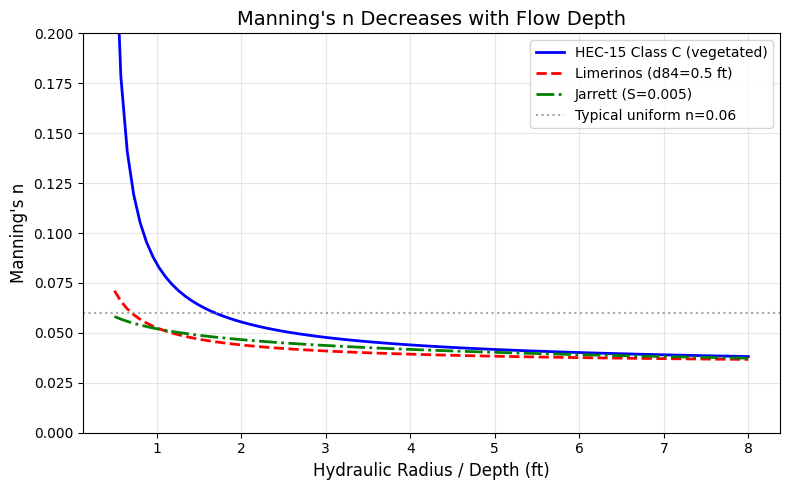

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plot Manning's n vs depth for three formulas ---
depths = np.linspace(0.5, 8.0, 100)  # ft
S = 0.005   # slope
d84 = 0.5   # ft (gravel bed)

# HEC-15 Class C (moderate retardance)
X_C = 30.2
n_hec15 = depths**(1/6) / (X_C + 19.97 * np.log10(depths**1.4 * S**0.4))
n_hec15 = np.clip(n_hec15, 0.01, 0.3)

# Limerinos (1970)
n_lim = (0.0926 * depths**(1/6)) / (1.16 + 2.0 * np.log10(depths / d84))
n_lim = np.clip(n_lim, 0.01, 0.3)

# Jarrett (1984)
n_jar = 0.39 * S**0.38 * depths**(-0.16)
n_jar = np.clip(n_jar, 0.01, 0.3)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, n_hec15, 'b-', linewidth=2, label='HEC-15 Class C (vegetated)')
ax.plot(depths, n_lim, 'r--', linewidth=2, label=f'Limerinos (d84={d84} ft)')
ax.plot(depths, n_jar, 'g-.', linewidth=2, label=f'Jarrett (S={S})')
ax.axhline(y=0.06, color='gray', linestyle=':', alpha=0.7, label='Typical uniform n=0.06')
ax.set_xlabel('Hydraulic Radius / Depth (ft)', fontsize=12)
ax.set_ylabel("Manning's n", fontsize=12)
ax.set_title("Manning's n Decreases with Flow Depth", fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.20)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


In [2]:
from pathlib import Path
import sys
import logging
import contextlib
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import rasterio
from rasterio.enums import Resampling

# nbconvert starts kernels from the notebook directory. Walk upward to the repo root
# so this example uses the active checkout rather than an installed package.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "ras_commander" / "__init__.py").exists() and (candidate / "examples").exists():
        REPO_ROOT = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate ras-commander repository root")

repo_root_str = str(REPO_ROOT)
if sys.path[0] != repo_root_str:
    if repo_root_str in sys.path:
        sys.path.remove(repo_root_str)
    sys.path.insert(0, repo_root_str)

from ras_commander import (  # noqa: E402
    init_ras_project, RasCmdr, RasExamples, RasMap, RasPreprocess,
    get_logger,
)
from ras_commander.geom import (  # noqa: E402
    GeomCrossSection, GeomLandCover, GeomStorage,
)
from ras_commander.hdf import (  # noqa: E402
    HdfFluvialPluvial, HdfLandCover, HdfMesh,
    HdfResultsMesh, HdfResultsPlan, HdfXsec,
)

# Keep the notebook readable; terminal logs capture detailed ras-commander traces.
logging.getLogger("ras_commander").setLevel(logging.WARNING)
for logger_name in list(logging.root.manager.loggerDict):
    if logger_name.startswith("ras_commander"):
        logging.getLogger(logger_name).setLevel(logging.WARNING)
logging.getLogger("ras_commander.hdf.HdfResultsPlan").setLevel(logging.ERROR)

logger = get_logger(__name__)

print(f"Using ras_commander from: {Path(sys.modules['ras_commander'].__file__).parent}")


Using ras_commander from: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-clb903-landcover-pipeline\ras_commander


## Configuration

In [3]:
PROJECT_NAME = "Muncie"
RAS_VERSION = "7.0"
PLAN_NUMBER = "04"          # Muncie plan using g04 with a Manning's n calibration region
MESH_NAME = "2D Interior Area"
GEOM_NUMBER = "04"
CALIBRATION_GEOM_NUMBER = "04"
CALIBRATION_REGION_NAME = "Flat Area"
RAS_LINUX_EXE_DIR = "/mnt/c/Program Files (x86)/HEC/HEC-RAS/7.0/Linux"

WORK_DIR = REPO_ROOT / "working" / "414_depth_varying_mannings_n"
PROJECT_DIR = WORK_DIR / "example_projects"
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Depth-varying n parameters (exponential decay toward asymptote)
N_ASYMPTOTE = 0.045   # Deep-flow Manning's n
DEPTH_HALF = 1.0      # Depth at which n decays to about 37% of excess above asymptote
EXTENSION_HEIGHT = 5.0
ELEVATION_STEP = 0.5

## Step 1: Extract Three Projects and Establish Model Context

Three independent copies keep the comparison controlled:

- **Baseline** — original face tables and uniform n=0.06
- **Extension-only control** — extended tables with uniform n=0.06
- **Modified** — the identical extended tables with depth-varying n

The context figure uses public `ras-commander` geometry, terrain-reference,
project DataFrame, and boundary-condition APIs before any table edits.


Baseline: working\414_depth_varying_mannings_n\example_projects\Muncie_414_baseline
Extension-only control: working\414_depth_varying_mannings_n\example_projects\Muncie_414_extension_control
Modified: working\414_depth_varying_mannings_n\example_projects\Muncie_414_modified


Model item,Evidence
Plan,04 — Unsteady Run with 2D 50ft User n Value R
Simulation,24 hours; 10-second computation interval
1D geometry,White River / Muncie; 61 cross sections
1D/2D coupling,2 lateral structures
2D geometry,"2D Interior Area; 5,391 active cells"
Upstream BC,"Flow hydrograph, 13,500–21,000 cfs in run window"
Downstream BC,"Normal depth, friction slope 0.00064"
Terrain,TerrainWithChannel.hdf
Solver,HEC-RAS 7.0 configured; exact runtime build asserted after solves


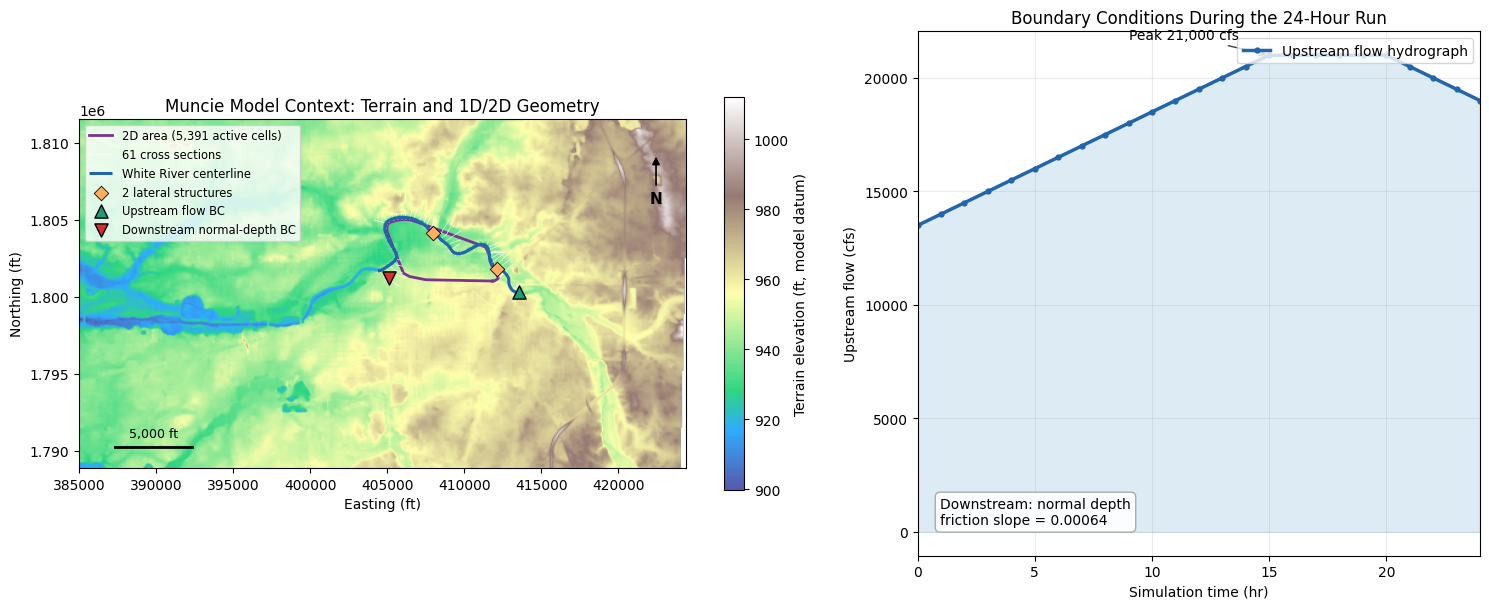

In [4]:
RasExamples.get_example_projects(RAS_VERSION)
baseline_path = RasExamples.extract_project(
    PROJECT_NAME, output_path=PROJECT_DIR, suffix="414_baseline"
)
control_path = RasExamples.extract_project(
    PROJECT_NAME, output_path=PROJECT_DIR, suffix="414_extension_control"
)
modified_path = RasExamples.extract_project(
    PROJECT_NAME, output_path=PROJECT_DIR, suffix="414_modified"
)

print(f"Baseline: {baseline_path.relative_to(REPO_ROOT)}")
print(f"Extension-only control: {control_path.relative_to(REPO_ROOT)}")
print(f"Modified: {modified_path.relative_to(REPO_ROOT)}")

baseline_ras = init_ras_project(
    baseline_path, RAS_VERSION, ras_object="new", accept_tcu=True
)
plan_row = baseline_ras.plan_df[
    baseline_ras.plan_df["plan_number"] == PLAN_NUMBER
].iloc[0]
geom_row = baseline_ras.geom_df[
    baseline_ras.geom_df["geom_number"] == GEOM_NUMBER
].iloc[0]
baseline_geom = Path(geom_row["full_path"])
baseline_geom_hdf = Path(geom_row["hdf_path"])

# Public geometry APIs distinguish 61 cross sections from two type-6
# lateral-structure nodes that couple the White River reach to the 2D area.
geometry_nodes = GeomCrossSection.get_cross_sections(baseline_geom)
cross_section_nodes = geometry_nodes[geometry_nodes["Type"] == 1].copy()
lateral_nodes = geometry_nodes[geometry_nodes["Type"] == 6].copy()
xs_gdf = HdfXsec.get_cross_sections(baseline_geom_hdf)
river_gdf = HdfXsec.get_river_centerlines(baseline_geom_hdf)
mesh_points = HdfMesh.get_mesh_cell_points(baseline_geom_hdf)
mesh_points = mesh_points[mesh_points["mesh_name"] == MESH_NAME].copy()
terrain_layers = RasMap.list_terrain_layers(
    baseline_path,
    ras_object=baseline_ras,
)
terrain_match = terrain_layers[
    terrain_layers["name"] == "TerrainWithChannel"
]
assert len(terrain_match) == 1, (
    "Expected exactly one registered TerrainWithChannel layer; "
    f"available: {terrain_layers['name'].tolist()}"
)
terrain_path_returned = Path(
    terrain_match["resolved_path"].iloc[0]
)

# Public path readers can return an absolute path, a path relative to the
# repository, or a path relative to the extracted project. Resolve all
# three forms without ever prepending the project to an absolute path.
def resolve_project_artifact(returned_path, project_path):
    candidate = Path(returned_path)
    if candidate.is_absolute():
        candidates = [candidate]
    else:
        candidates = [
            REPO_ROOT / candidate,
            Path(project_path) / candidate,
            Path(project_path).parent / candidate,
        ]
    resolved = next(
        (path.resolve() for path in candidates if path.exists()),
        None,
    )
    if resolved is None:
        checked = ", ".join(str(path) for path in candidates)
        raise FileNotFoundError(
            f"Could not resolve project artifact {returned_path!s}; "
            f"checked: {checked}"
        )
    return resolved


terrain_hdf_path = resolve_project_artifact(
    terrain_path_returned,
    baseline_path,
)
assert terrain_hdf_path.name == "TerrainWithChannel.hdf"
terrain_path = terrain_hdf_path.with_suffix(".vrt")
assert terrain_path.exists(), (
    f"Registered terrain raster companion missing: {terrain_path}"
)

assert len(cross_section_nodes) == 61
assert len(lateral_nodes) == 2
assert int(geom_row["mesh_cell_count"]) == 5391
assert terrain_path.exists()
assert len(xs_gdf) == 61
assert len(river_gdf) == 1

# Boundary conditions come from the project boundary DataFrame. The 24-hour
# simulation uses the first 25 hourly ordinates of the upstream hydrograph.
boundaries = baseline_ras.boundaries_df[
    baseline_ras.boundaries_df["unsteady_number"] == str(
        plan_row["unsteady_number"]
    )
].copy()
upstream_bc = boundaries[
    boundaries["bc_type"] == "Flow Hydrograph"
].iloc[0]
downstream_bc = boundaries[
    boundaries["bc_type"] == "Normal Depth"
].iloc[0]
simulation_inflow = np.asarray(
    list(upstream_bc["hydrograph_values"])[:25],
    dtype=float,
)
downstream_slope = float(
    str(downstream_bc["Friction Slope"]).split(",")[0]
)
assert simulation_inflow.min() == 13500
assert simulation_inflow.max() == 21000
assert np.isclose(downstream_slope, 0.00064)

model_context = pd.DataFrame(
    [
        ("Plan", f"{PLAN_NUMBER} — {plan_row['Plan Title']}"),
        ("Simulation", "24 hours; 10-second computation interval"),
        ("1D geometry", "White River / Muncie; 61 cross sections"),
        ("1D/2D coupling", "2 lateral structures"),
        ("2D geometry", f"{MESH_NAME}; 5,391 active cells"),
        ("Upstream BC", "Flow hydrograph, 13,500–21,000 cfs in run window"),
        ("Downstream BC", "Normal depth, friction slope 0.00064"),
    ("Terrain", terrain_hdf_path.name),
        (
            "Solver",
            "HEC-RAS 7.0 configured; exact runtime build asserted after solves",
        ),
    ],
    columns=["Model item", "Evidence"],
)
display(model_context.style.hide(axis="index"))

# Read the registered layer's companion VRT for orientation. The authoritative
# TerrainWithChannel HDF path comes from RasMap.list_terrain_layers().
with rasterio.open(terrain_path) as terrain_src:
    out_height = min(500, terrain_src.height)
    out_width = min(500, terrain_src.width)
    terrain = terrain_src.read(
        1,
        out_shape=(out_height, out_width),
        masked=True,
        resampling=Resampling.bilinear,
    )
    terrain_extent = (
        terrain_src.bounds.left,
        terrain_src.bounds.right,
        terrain_src.bounds.bottom,
        terrain_src.bounds.top,
    )

river_line = river_gdf.geometry.iloc[0]
xs_rs = pd.to_numeric(xs_gdf["RS"], errors="coerce")
upstream_xs = xs_gdf.loc[xs_rs.idxmax()].geometry.centroid
downstream_xs = xs_gdf.loc[xs_rs.idxmin()].geometry.centroid
max_river_station = float(xs_rs.max())
lateral_points = [
    river_line.interpolate(
        np.clip(
            max_river_station - float(station),
            0.0,
            river_line.length,
        )
    )
    for station in pd.to_numeric(lateral_nodes["RS"], errors="raise")
]

fig, axes = plt.subplots(
    1, 2, figsize=(15, 6.2), gridspec_kw={"width_ratios": [1.35, 1]}
)

ax = axes[0]
terrain_image = ax.imshow(
    terrain,
    extent=terrain_extent,
    origin="upper",
    cmap="terrain",
    alpha=0.82,
)
mesh_outline = mesh_points.geometry.union_all().convex_hull
ax.plot(
    *mesh_outline.exterior.xy,
    color="#7b3294",
    linewidth=2.0,
    label="2D area (5,391 active cells)",
)
xs_gdf.plot(
    ax=ax,
    color="white",
    linewidth=0.55,
    alpha=0.8,
    label="61 cross sections",
)
river_gdf.plot(
    ax=ax,
    color="#2166ac",
    linewidth=2.2,
    label="White River centerline",
)
ax.scatter(
    [point.x for point in lateral_points],
    [point.y for point in lateral_points],
    marker="D",
    s=55,
    color="#fdae61",
    edgecolor="black",
    linewidth=0.6,
    label="2 lateral structures",
    zorder=5,
)
ax.scatter(
    [upstream_xs.x],
    [upstream_xs.y],
    marker="^",
    s=90,
    color="#1b9e77",
    edgecolor="black",
    label="Upstream flow BC",
    zorder=6,
)
ax.scatter(
    [downstream_xs.x],
    [downstream_xs.y],
    marker="v",
    s=90,
    color="#d73027",
    edgecolor="black",
    label="Downstream normal-depth BC",
    zorder=6,
)
ax.set_title("Muncie Model Context: Terrain and 1D/2D Geometry")
ax.set_xlabel("Easting (ft)")
ax.set_ylabel("Northing (ft)")
ax.set_aspect("equal")
ax.legend(fontsize=8.3, loc="best")
fig.colorbar(
    terrain_image,
    ax=ax,
    label="Terrain elevation (ft, model datum)",
    shrink=0.75,
)
ax.annotate(
    "N",
    xy=(0.95, 0.90),
    xytext=(0.95, 0.76),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    fontsize=11,
    fontweight="bold",
    arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 1.2},
)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
scale_len = 5000
scale_x = xmin + 0.06 * (xmax - xmin)
scale_y = ymin + 0.06 * (ymax - ymin)
ax.plot(
    [scale_x, scale_x + scale_len],
    [scale_y, scale_y],
    color="black",
    linewidth=2,
)
ax.text(
    scale_x + scale_len / 2,
    scale_y + 0.02 * (ymax - ymin),
    "5,000 ft",
    ha="center",
    va="bottom",
    fontsize=9,
)

ax = axes[1]
hours = np.arange(len(simulation_inflow))
ax.plot(
    hours,
    simulation_inflow,
    color="#2166ac",
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Upstream flow hydrograph",
)
ax.fill_between(hours, simulation_inflow, color="#67a9cf", alpha=0.22)
peak_index = int(np.argmax(simulation_inflow))
ax.annotate(
    f"Peak {simulation_inflow[peak_index]:,.0f} cfs",
    xy=(peak_index, simulation_inflow[peak_index]),
    xytext=(peak_index - 6, simulation_inflow[peak_index] + 700),
    arrowprops={"arrowstyle": "->", "color": "0.25"},
)
ax.text(
    0.04,
    0.06,
    "Downstream: normal depth\nfriction slope = 0.00064",
    transform=ax.transAxes,
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "0.65",
        "alpha": 0.93,
    },
)
ax.set_title("Boundary Conditions During the 24-Hour Run")
ax.set_xlabel("Simulation time (hr)")
ax.set_ylabel("Upstream flow (cfs)")
ax.set_xlim(0, 24)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()


## Step 2: Read Current Manning's n Settings

Muncie uses a **uniform** Manning's n (0.06) for the entire 2D flow area.
The land cover table exists but is inactive because *Spatially Varied Manning's
on Faces* is disabled.

In [5]:
baseline_geom = baseline_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}"

settings = GeomStorage.get_2d_flow_area_settings(baseline_geom)
area_row = settings[settings['name'] == MESH_NAME].iloc[0]
original_n = area_row['mannings_n']
spatially_varied = area_row.get('spatially_varied_mann_on_faces', False)

print(f"2D Flow Area: '{MESH_NAME}'")
print(f"  Uniform Manning's n: {original_n}")
print(f"  Spatially varied: {spatially_varied}")

original_mannings = GeomLandCover.get_base_mannings_n(baseline_geom)
print(f"\nLand cover table ({len(original_mannings)} classes):")
print(original_mannings.to_string(index=False))


2D Flow Area: '2D Interior Area'
  Uniform Manning's n: 0.06
  Spatially varied: False

Land cover table (6 classes):
Table Number            Land Cover Name  Base Mannings n Value
           6                   building                 100.00
           6 medium density residential                   0.08
           6                 open space                   0.04
           6                       park                   0.06
           6                      trees                   0.12
           6                      urban                   0.10


## Step 3: Run Baseline Model

The baseline project is computed first with the original uniform Manning's n. The
geometry preprocessor generates the reference face property tables, and the plan
HDF stores the maximum water surface elevations used for comparison.


In [6]:
baseline_ras = init_ras_project(
    baseline_path, RAS_VERSION, ras_object="new", accept_tcu=True
)
print("Preprocessing baseline model on Windows...")
baseline_preprocess = RasPreprocess.preprocess_plan(
    PLAN_NUMBER,
    ras_object=baseline_ras,
    max_wait=300,
    clear_existing=True,
)
assert baseline_preprocess.success, baseline_preprocess.error
assert baseline_preprocess.tmp_hdf_path and Path(baseline_preprocess.tmp_hdf_path).exists()
print(f"Baseline tmp HDF: {Path(baseline_preprocess.tmp_hdf_path).name}")

print("Running baseline model with native Linux RasUnsteady...")
baseline_result = RasCmdr.compute_plan_linux(
    PLAN_NUMBER,
    ras_exe_dir=RAS_LINUX_EXE_DIR,
    ras_object=baseline_ras,
    timeout_sec=7200,
    num_cores=2,
    retry=False,
)
assert baseline_result.success, "Baseline Linux solver run failed"
baseline_ras = init_ras_project(
    baseline_path, RAS_VERSION, ras_object="new", accept_tcu=True
)

base_hdf_path = Path(baseline_ras.plan_df.loc[
    baseline_ras.plan_df['plan_number'] == PLAN_NUMBER, 'HDF_Results_Path'
].iloc[0])
print("Baseline Linux solver result and promoted HDF passed public validation")

baseline_geom_hdf = baseline_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}.hdf"
base_tables = HdfMesh.get_mesh_face_property_tables(base_hdf_path)
base_df = base_tables[MESH_NAME]
n_col = "Manning's n"

print(f"\nBaseline output face tables: {base_df['Face ID'].nunique()} faces, {len(base_df)} rows")
print(f"Baseline mean n: {base_df[n_col].mean():.4f}")
assert base_df['Face ID'].nunique() > 0, "Expected face property tables"


Preprocessing baseline model on Windows...


Baseline tmp HDF: Muncie.p04.tmp.hdf
Running baseline model with native Linux RasUnsteady...


Baseline Linux solver result and promoted HDF passed public validation

Baseline output face tables: 11164 faces, 47055 rows
Baseline mean n: 0.0600


## Step 4: Build Identical Extended Tables, Then Vary Only n

Both comparison projects are preprocessed on Windows to create solver-ready
HEC-RAS 7.0 `.p##.tmp.hdf` files. The extension-only control and modified
projects receive **identical Elevation, Area, and Wetted Perimeter rows**.
The control retains uniform n=0.06; the modified case applies the
depth-varying-n transform. Assertions prove that n is the only face-table
difference between the two solver inputs.

The geometry HDF and plan/output HDF are not edited. The guarded APIs verify
the temporary-result role and schema, require
`acknowledge_unsupported=True`, retain a unique full-file backup for each
write, and verify readback.


In [7]:
def vegetal_retardance(elevation, depth, current_n):
    """Exponential decay: n decreases from current_n toward the asymptote."""
    if depth <= 0:
        return current_n
    return N_ASYMPTOTE + (
        current_n - N_ASYMPTOTE
    ) * np.exp(-depth / DEPTH_HALF)


def depth_varying_extension_n(depth, _last_transformed_n):
    """Continue the original uniform-n decay curve into extension rows."""
    if depth <= 0:
        return original_n
    return N_ASYMPTOTE + (
        original_n - N_ASYMPTOTE
    ) * np.exp(-depth / DEPTH_HALF)


def uniform_control_n(_depth, _last_n):
    """Keep the extension-only control at uniform n=0.06."""
    return original_n


def sorted_face_table(frame):
    return frame.sort_values(["Face ID", "Elevation"]).reset_index(drop=True)


# Preprocess the extension-only control.
control_ras = init_ras_project(
    control_path, RAS_VERSION, ras_object="new", accept_tcu=True
)
print("Preprocessing extension-only control on Windows...")
control_preprocess = RasPreprocess.preprocess_plan(
    PLAN_NUMBER,
    ras_object=control_ras,
    max_wait=300,
    clear_existing=True,
)
assert control_preprocess.success, control_preprocess.error
control_tmp_hdf = Path(control_preprocess.tmp_hdf_path)
assert control_tmp_hdf.exists()
control_pre_df = HdfMesh.get_mesh_face_property_tables(
    control_tmp_hdf
)[MESH_NAME]

# Preprocess the modified project from the same source.
modified_ras = init_ras_project(
    modified_path, RAS_VERSION, ras_object="new", accept_tcu=True
)
print("Preprocessing modified model on Windows...")
modified_preprocess = RasPreprocess.preprocess_plan(
    PLAN_NUMBER,
    ras_object=modified_ras,
    max_wait=300,
    clear_existing=True,
)
assert modified_preprocess.success, modified_preprocess.error
modified_tmp_hdf = Path(modified_preprocess.tmp_hdf_path)
assert modified_tmp_hdf.exists()
pre_df = HdfMesh.get_mesh_face_property_tables(modified_tmp_hdf)[MESH_NAME]

# Confirm identical preprocessed starting tables.
control_pre_sorted = sorted_face_table(control_pre_df)
pre_sorted = sorted_face_table(pre_df)
assert control_pre_sorted.shape == pre_sorted.shape
np.testing.assert_array_equal(
    control_pre_sorted["Face ID"].to_numpy(),
    pre_sorted["Face ID"].to_numpy(),
)
np.testing.assert_allclose(
    control_pre_sorted[
        ["Elevation", "Area", "Wetted Perimeter", "Manning's n"]
    ].to_numpy(),
    pre_sorted[
        ["Elevation", "Area", "Wetted Perimeter", "Manning's n"]
    ].to_numpy(),
    rtol=1e-7,
    atol=1e-7,
)

n_col = "Manning's n"
sample_face = 1050
if sample_face not in set(pre_df["Face ID"]):
    sample_face = int(pre_df["Face ID"].iloc[len(pre_df) // 2])
pre_sample = pre_df[pre_df["Face ID"] == sample_face].copy()
assert not pre_sample.empty

max_elev = pre_df["Elevation"].max()
target_elev = max_elev + EXTENSION_HEIGHT

# Extend the control without changing n.
control_extension_report = HdfMesh.extend_linux_tmp_face_property_tables(
    hdf_path=control_tmp_hdf,
    mesh_name=MESH_NAME,
    extension_elevation=target_elev,
    mannings_n_func=uniform_control_n,
    elevation_step=ELEVATION_STEP,
    face_ids=None,
    pin_tables=False,
    acknowledge_unsupported=True,
)
control_extension_backup = Path(
    control_extension_report["backup_path"]
)
assert control_extension_report["rows_added"]
assert control_extension_backup.exists()
control_pinned_backup = HdfMesh.set_mesh_pinned_attribute(
    control_tmp_hdf,
    MESH_NAME,
    pinned=True,
    acknowledge_unsupported=True,
)
assert control_pinned_backup.exists()
control_ext_df = HdfMesh.get_mesh_face_property_tables(
    control_tmp_hdf
)[MESH_NAME]
np.testing.assert_allclose(
    control_ext_df[n_col].to_numpy(),
    original_n,
    rtol=0,
    atol=1e-7,
)

# Apply depth-varying n to existing rows, then extend to the same elevation.
transform_report = HdfMesh.transform_linux_tmp_face_mannings_n(
    hdf_path=modified_tmp_hdf,
    mesh_name=MESH_NAME,
    mannings_n_func=vegetal_retardance,
    face_ids=None,
    pin_tables=False,
    acknowledge_unsupported=True,
)
transform_backup = Path(transform_report["backup_path"])
expected_faces = pre_df["Face ID"].nunique()
assert transform_report["faces_modified"] == expected_faces
assert transform_backup.exists()

extension_report = HdfMesh.extend_linux_tmp_face_property_tables(
    hdf_path=modified_tmp_hdf,
    mesh_name=MESH_NAME,
    extension_elevation=target_elev,
    mannings_n_func=depth_varying_extension_n,
    elevation_step=ELEVATION_STEP,
    face_ids=None,
    pin_tables=False,
    acknowledge_unsupported=True,
)
rows_added = extension_report["rows_added"]
extension_backup = Path(extension_report["backup_path"])
assert rows_added
assert extension_backup.exists()
assert rows_added == control_extension_report["rows_added"]

pinned_backup = HdfMesh.set_mesh_pinned_attribute(
    modified_tmp_hdf,
    MESH_NAME,
    pinned=True,
    acknowledge_unsupported=True,
)
assert pinned_backup.exists()
assert len(
    {
        control_extension_backup,
        control_pinned_backup,
        transform_backup,
        extension_backup,
        pinned_backup,
    }
) == 5

ext_df = HdfMesh.get_mesh_face_property_tables(modified_tmp_hdf)[MESH_NAME]
control_ext_sorted = sorted_face_table(control_ext_df)
ext_sorted = sorted_face_table(ext_df)
assert control_ext_sorted.shape == ext_sorted.shape
np.testing.assert_array_equal(
    control_ext_sorted["Face ID"].to_numpy(),
    ext_sorted["Face ID"].to_numpy(),
)
np.testing.assert_allclose(
    control_ext_sorted[
        ["Elevation", "Area", "Wetted Perimeter"]
    ].to_numpy(),
    ext_sorted[
        ["Elevation", "Area", "Wetted Perimeter"]
    ].to_numpy(),
    rtol=1e-7,
    atol=1e-7,
)
assert not np.allclose(
    control_ext_sorted[n_col].to_numpy(),
    ext_sorted[n_col].to_numpy(),
)

control_ext_sample = control_ext_df[
    control_ext_df["Face ID"] == sample_face
].copy()
ext_sample = ext_df[ext_df["Face ID"] == sample_face].copy()
assert len(control_ext_sample) == len(ext_sample) > len(pre_sample)
assert ext_sample["Elevation"].max() >= (
    target_elev - ELEVATION_STEP - 0.01
)
assert ext_df[n_col].round(6).nunique() > 1
assert ext_df[n_col].min() < original_n - 0.001

print(
    f"Face {sample_face}: {len(pre_sample)} original rows -> "
    f"{len(ext_sample)} identical extended rows per scenario"
)
print(
    "Control/modified Elevation, Area, and Wetted Perimeter tables "
    "match exactly within 1e-7."
)
print(
    f"Control n={control_ext_df[n_col].iloc[0]:.3f}; "
    f"modified n range={ext_df[n_col].min():.4f}–"
    f"{ext_df[n_col].max():.4f}"
)


Preprocessing extension-only control on Windows...


Preprocessing modified model on Windows...


Face 1050: 19 original rows -> 72 identical extended rows per scenario
Control/modified Elevation, Area, and Wetted Perimeter tables match exactly within 1e-7.
Control n=0.060; modified n range=0.0450–0.0600


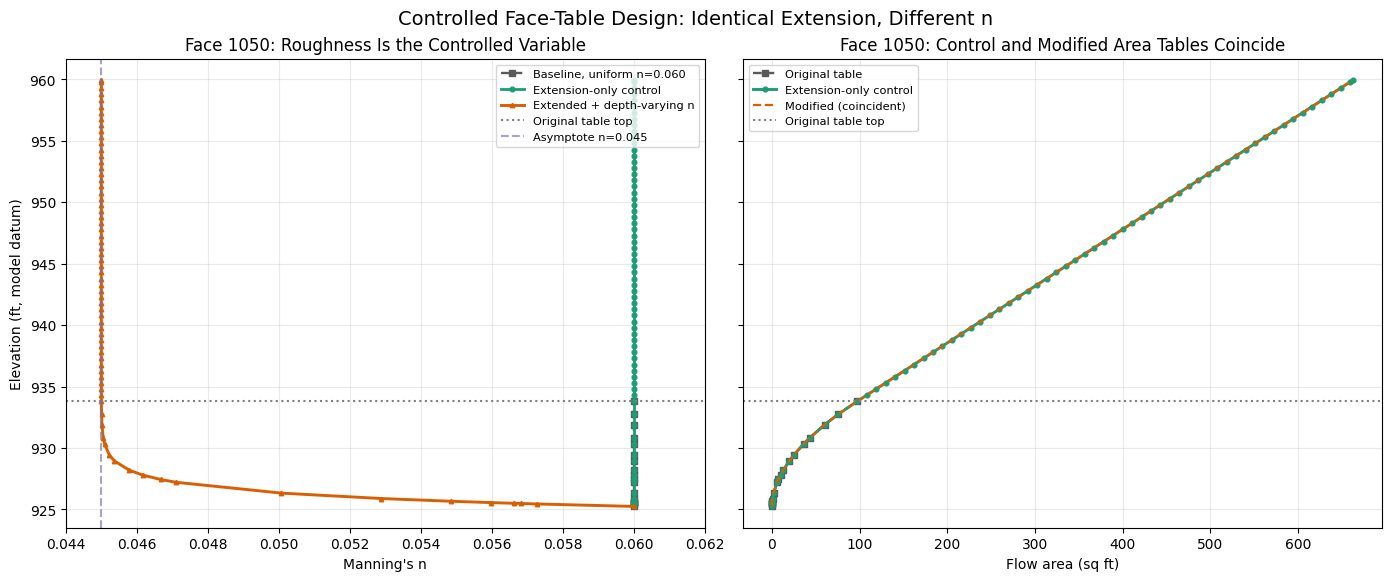

In [8]:
# --- Figure: one representative face across all three table states ---
fig, axes = plt.subplots(
    1, 2, figsize=(13.8, 5.7), sharey=True, constrained_layout=True
)

orig_max_elev = pre_sample["Elevation"].max()
roughness_xlim = (
    min(float(ext_sample[n_col].min()), N_ASYMPTOTE) - 0.001,
    max(float(original_n), float(ext_sample[n_col].max())) + 0.002,
)

ax = axes[0]
ax.plot(
    pre_sample[n_col],
    pre_sample["Elevation"],
    color="0.35",
    linestyle="--",
    marker="s",
    markersize=4,
    label=f"Baseline, uniform n={original_n:.3f}",
    linewidth=1.7,
)
ax.plot(
    control_ext_sample[n_col],
    control_ext_sample["Elevation"],
    color="#1b9e77",
    marker="o",
    markersize=3.4,
    label="Extension-only control",
    linewidth=2.0,
)
ax.plot(
    ext_sample[n_col],
    ext_sample["Elevation"],
    color="#d95f02",
    marker="^",
    markersize=3.2,
    label="Extended + depth-varying n",
    linewidth=2.1,
)
ax.axhline(
    orig_max_elev,
    color="gray",
    linestyle=":",
    label="Original table top",
)
ax.axvline(
    N_ASYMPTOTE,
    color="#7570b3",
    linestyle="--",
    alpha=0.65,
    label=f"Asymptote n={N_ASYMPTOTE:.3f}",
)
ax.set_xlim(*roughness_xlim)
ax.set_xlabel("Manning's n")
ax.set_ylabel("Elevation (ft, model datum)")
ax.set_title(f"Face {sample_face}: Roughness Is the Controlled Variable")
ax.legend(fontsize=8.2, loc="upper right")
ax.grid(True, alpha=0.28)

ax = axes[1]
ax.plot(
    pre_sample["Area"],
    pre_sample["Elevation"],
    color="0.35",
    linestyle="--",
    marker="s",
    markersize=4,
    label="Original table",
    linewidth=1.7,
)
ax.plot(
    control_ext_sample["Area"],
    control_ext_sample["Elevation"],
    color="#1b9e77",
    marker="o",
    markersize=3.4,
    label="Extension-only control",
    linewidth=2.1,
)
ax.plot(
    ext_sample["Area"],
    ext_sample["Elevation"],
    color="#d95f02",
    linestyle="--",
    linewidth=1.6,
    label="Modified (coincident)",
)
ax.axhline(
    orig_max_elev,
    color="gray",
    linestyle=":",
    label="Original table top",
)
ax.set_xlabel("Flow area (sq ft)")
ax.set_title(
    f"Face {sample_face}: Control and Modified Area Tables Coincide"
)
ax.legend(fontsize=8.2, loc="upper left")
ax.grid(True, alpha=0.28)

fig.suptitle(
    "Controlled Face-Table Design: Identical Extension, Different n",
    fontsize=14,
)
plt.show()


## Step 5: Run Extension-Control and Modified Linux Solvers

The Windows solver rebuilds face-property tables at startup, so this notebook
does not call `compute_plan()` after the guarded temporary-HDF edits. Each
edited `.tmp.hdf` is passed directly to native Linux `RasUnsteady` through
`RasCmdr.compute_plan_linux()`. The `Pinned` attribute is informational only;
persistence is proved by re-reading both output HDFs after the solves.


In [9]:
# The extension-only control consumes its uniform-n extended table.
control_ras = init_ras_project(
    control_path, RAS_VERSION, ras_object="new", accept_tcu=True
)
control_pre_solver_df = HdfMesh.get_mesh_face_property_tables(
    control_tmp_hdf
)[MESH_NAME]
assert len(control_pre_solver_df) == len(control_ext_df)
np.testing.assert_allclose(
    control_pre_solver_df[n_col].to_numpy(),
    original_n,
    rtol=0,
    atol=1e-7,
)

print(
    "Running extension-only control with native Linux RasUnsteady "
    "from the edited .tmp.hdf..."
)
control_result = RasCmdr.compute_plan_linux(
    PLAN_NUMBER,
    ras_exe_dir=RAS_LINUX_EXE_DIR,
    ras_object=control_ras,
    timeout_sec=7200,
    num_cores=2,
    retry=False,
)
assert control_result.success, "Extension-only control Linux solve failed"
control_ras = init_ras_project(
    control_path, RAS_VERSION, ras_object="new", accept_tcu=True
)
control_hdf_path = Path(
    control_ras.plan_df.loc[
        control_ras.plan_df["plan_number"] == PLAN_NUMBER,
        "HDF_Results_Path",
    ].iloc[0]
)

# The modified run consumes the same extended E/A/WP tables with varied n.
modified_ras = init_ras_project(
    modified_path, RAS_VERSION, ras_object="new", accept_tcu=True
)
pre_solver_tmp_df = HdfMesh.get_mesh_face_property_tables(
    modified_tmp_hdf
)[MESH_NAME]
assert len(pre_solver_tmp_df) == len(ext_df)
assert pre_solver_tmp_df[n_col].min() < original_n - 0.001

print(
    "Running modified model with native Linux RasUnsteady "
    "from the edited .tmp.hdf..."
)
modified_result = RasCmdr.compute_plan_linux(
    PLAN_NUMBER,
    ras_exe_dir=RAS_LINUX_EXE_DIR,
    ras_object=modified_ras,
    timeout_sec=7200,
    num_cores=2,
    retry=False,
)
assert modified_result.success, "Modified Linux solve failed"
modified_ras = init_ras_project(
    modified_path, RAS_VERSION, ras_object="new", accept_tcu=True
)
mod_hdf_path = Path(
    modified_ras.plan_df.loc[
        modified_ras.plan_df["plan_number"] == PLAN_NUMBER,
        "HDF_Results_Path",
    ].iloc[0]
)

assert baseline_result.success
assert control_result.success
assert modified_result.success
print("All three RasCmdr.compute_plan_linux() calls returned success.")


Running extension-only control with native Linux RasUnsteady from the edited .tmp.hdf...


Running modified model with native Linux RasUnsteady from the edited .tmp.hdf...


All three RasCmdr.compute_plan_linux() calls returned success.


## Step 6: Verify Persistence, Completion, Volume Error, and Hydraulic Effect

First, the output HDFs must preserve the solver-input tables. Next, public
`HdfResultsPlan` APIs verify that all three solutions finished successfully
and surface each run's volume-accounting error. The standard
`compute_plan_linux()` log supplies the exact runtime solver build.

Two contrasts are reported separately:

- **Extension effect:** extension-only control minus baseline
- **Isolated depth-varying-n effect:** modified minus extension-only control

All result comparisons are keyed to the geometry HDF's 5,391 active cell
polygons. This excludes non-active result records by cell identity instead
of inferring validity from a WSE sentinel value.

The extension effect is quantified rather than assumed to be neutral.


Qualified solve and volume-accounting evidence:


Scenario,Solution,Solver build,Volume error,Volume error (%),Units
Baseline,Unsteady Finished Successfully,HEC-RAS 7.0 April 2026,-0.711020,+0.001923,Acre Feet
Extension-only control,Unsteady Finished Successfully,HEC-RAS 7.0 April 2026,-0.710850,+0.001923,Acre Feet
Depth-varying n,Unsteady Finished Successfully,HEC-RAS 7.0 April 2026,-0.709299,+0.001919,Acre Feet


Hydraulic contrasts across all 5,391 active 2D cells (extension is reported separately, not assumed neutral):


Contrast,Active 2D cells,Cells |ΔWSE| > 0.001 ft,Mean ΔWSE (ft),Min ΔWSE (ft),Max ΔWSE (ft),95th pct |ΔWSE| (ft)
Extension-only control − baseline,5391,0,-0.0000,-0.0001,+0.0000,0.0000
Depth-varying n − extension-only control,5391,4890,-0.0637,-0.3347,+0.0164,0.2727


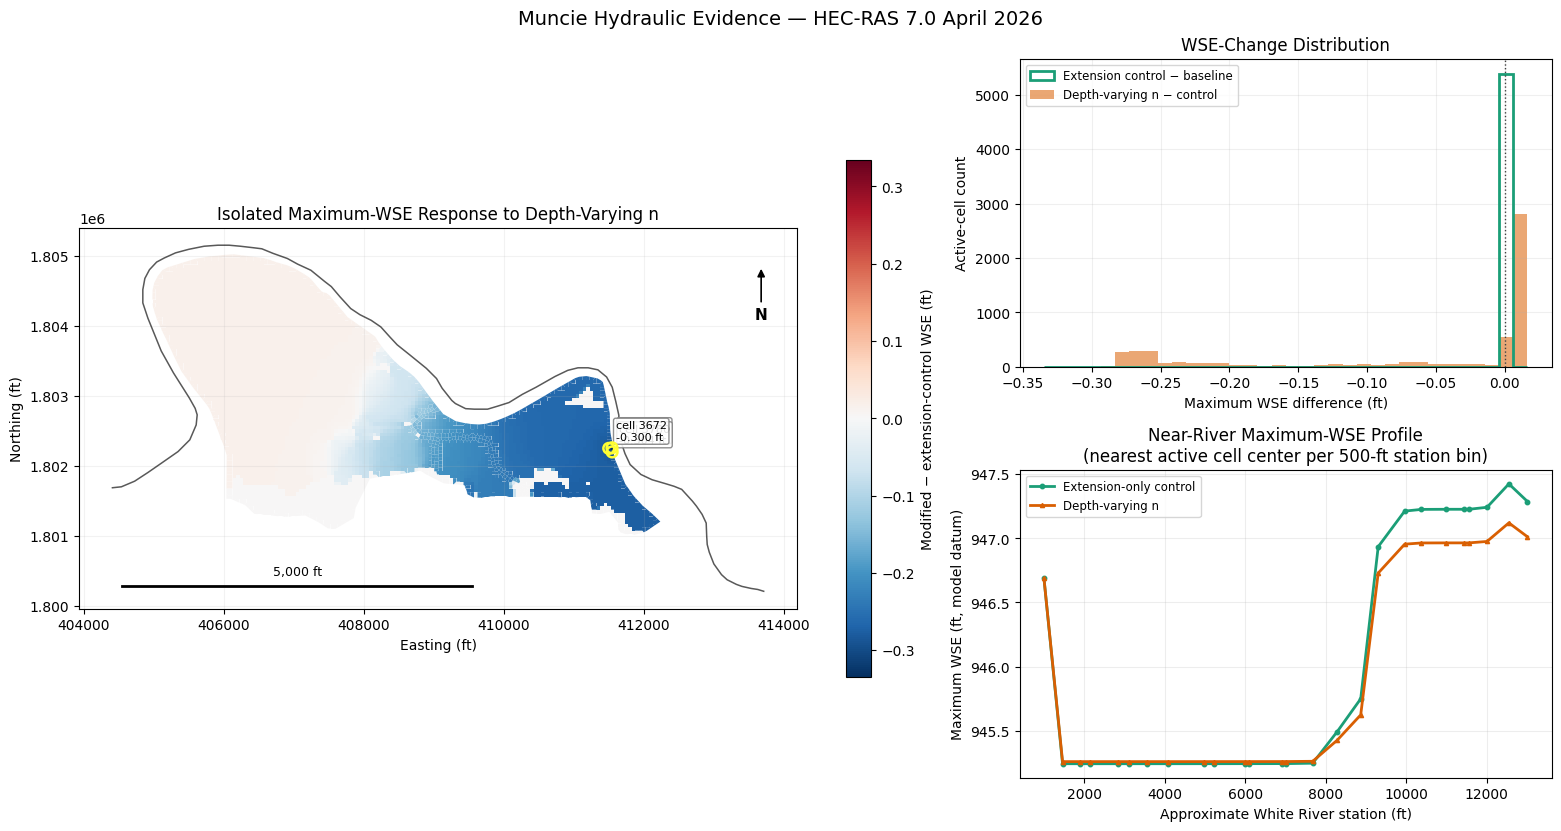

In [10]:
from matplotlib.colors import TwoSlopeNorm


def assert_table_persistence(before, after, label):
    before_sorted = sorted_face_table(before)
    after_sorted = sorted_face_table(after)
    assert before_sorted.shape == after_sorted.shape, label
    np.testing.assert_array_equal(
        before_sorted["Face ID"].to_numpy(),
        after_sorted["Face ID"].to_numpy(),
    )
    np.testing.assert_allclose(
        before_sorted[
            ["Elevation", "Area", "Wetted Perimeter", n_col]
        ].to_numpy(),
        after_sorted[
            ["Elevation", "Area", "Wetted Perimeter", n_col]
        ].to_numpy(),
        rtol=1e-5,
        atol=1e-6,
    )


control_post_df = HdfMesh.get_mesh_face_property_tables(
    control_hdf_path
)[MESH_NAME]
modified_post_df = HdfMesh.get_mesh_face_property_tables(
    mod_hdf_path
)[MESH_NAME]
assert_table_persistence(
    control_pre_solver_df,
    control_post_df,
    "Extension-only control table persistence failed",
)
assert_table_persistence(
    pre_solver_tmp_df,
    modified_post_df,
    "Modified table persistence failed",
)
np.testing.assert_allclose(
    sorted_face_table(control_post_df)[
        ["Elevation", "Area", "Wetted Perimeter"]
    ].to_numpy(),
    sorted_face_table(modified_post_df)[
        ["Elevation", "Area", "Wetted Perimeter"]
    ].to_numpy(),
    rtol=1e-5,
    atol=1e-6,
)
np.testing.assert_allclose(
    control_post_df[n_col].to_numpy(),
    original_n,
    rtol=0,
    atol=1e-6,
)
assert modified_post_df[n_col].round(6).nunique() > 1


def solver_build_from_standard_log(project_path):
    """Read the exact build line emitted by compute_plan_linux()."""
    log_path = Path(project_path) / f"compute_linux_{PLAN_NUMBER}.log"
    assert log_path.exists(), f"Missing standard Linux compute log: {log_path}"
    build_line = next(
        (
            line.strip()
            for line in log_path.read_text(
                encoding="utf-8", errors="replace"
            ).splitlines()
            if "Performing Unsteady Flow Simulation" in line
        ),
        "",
    )
    assert build_line, f"Solver identity missing from {log_path.name}"
    return build_line.replace(
        "Performing Unsteady Flow Simulation", ""
    ).strip()


run_records = []
for (
    label,
    result,
    project_path,
    hdf_path,
) in [
    ("Baseline", baseline_result, baseline_path, base_hdf_path),
    (
        "Extension-only control",
        control_result,
        control_path,
        control_hdf_path,
    ),
    ("Depth-varying n", modified_result, modified_path, mod_hdf_path),
]:
    assert result.success, f"{label} compute result was unsuccessful"
    summary = HdfResultsPlan.get_unsteady_summary(hdf_path)
    solution = str(summary["Solution"].iloc[0])
    assert "Finished Successfully" in solution, (
        f"{label} did not finish successfully: {solution}"
    )
    volume = HdfResultsPlan.get_volume_accounting(hdf_path)
    assert volume is not None and not volume.empty
    volume_error = float(volume["Error"].iloc[0])
    volume_error_percent = float(volume["Error Percent"].iloc[0])
    assert np.isfinite(volume_error)
    assert np.isfinite(volume_error_percent)
    solver_build = solver_build_from_standard_log(project_path)
    run_records.append(
        {
            "Scenario": label,
            "Solution": solution,
            "Solver build": solver_build,
            "Volume error": volume_error,
            "Volume error (%)": volume_error_percent,
            "Units": volume["Vol Accounting in"].iloc[0],
        }
    )

run_qualification = pd.DataFrame(run_records)
assert set(run_qualification["Solver build"]) == {
    "HEC-RAS 7.0 April 2026"
}
print("Qualified solve and volume-accounting evidence:")
display(
    run_qualification.style.hide(axis="index").format(
        {"Volume error": "{:+.6f}", "Volume error (%)": "{:+.6f}"}
    )
)

# Extract maximum WSE for all three scenarios.
base_wse_gdf = HdfResultsMesh.get_mesh_max_ws(base_hdf_path)
control_wse_gdf = HdfResultsMesh.get_mesh_max_ws(control_hdf_path)
mod_wse_gdf = HdfResultsMesh.get_mesh_max_ws(mod_hdf_path)
wse_col = next(
    column
    for column in base_wse_gdf.columns
    if column == "maximum_water_surface"
    or "water_surface" in column.lower()
    or "water surface" in column.lower()
)

base_wse = base_wse_gdf[
    base_wse_gdf["mesh_name"] == MESH_NAME
][["cell_id", wse_col]].copy()
control_wse = control_wse_gdf[
    control_wse_gdf["mesh_name"] == MESH_NAME
][["cell_id", wse_col]].copy()
modified_wse = mod_wse_gdf[
    mod_wse_gdf["mesh_name"] == MESH_NAME
][["cell_id", wse_col]].copy()

# HEC-RAS result arrays can include non-active/ghost records with 0.0 WSE.
# Select the qualified comparison population by active geometry cell ID,
# not by a permissive result-value threshold.
active_cells = HdfMesh.get_mesh_cell_polygons(baseline_geom_hdf)
active_cells = active_cells[
    active_cells["mesh_name"] == MESH_NAME
][["cell_id", "geometry"]].copy()
assert len(active_cells) == 5391
assert active_cells["cell_id"].is_unique

map_df = (
    active_cells.merge(
        base_wse.rename(columns={wse_col: "baseline_wse"}),
        on="cell_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        control_wse.rename(columns={wse_col: "control_wse"}),
        on="cell_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        modified_wse.rename(columns={wse_col: "modified_wse"}),
        on="cell_id",
        how="left",
        validate="one_to_one",
    )
)
result_columns = [
    "baseline_wse",
    "control_wse",
    "modified_wse",
]
assert len(map_df) == len(active_cells) == 5391
assert np.isfinite(map_df[result_columns].to_numpy()).all()
assert (
    map_df[result_columns].to_numpy() > 0
).all(), (
    "Muncie active cells should have positive model-datum WSE in all "
    "three completed runs"
)
map_df["extension_delta_wse"] = (
    map_df["control_wse"] - map_df["baseline_wse"]
)
map_df["isolated_delta_wse"] = (
    map_df["modified_wse"] - map_df["control_wse"]
)

def contrast_record(label, values):
    return {
        "Contrast": label,
        "Active 2D cells": len(values),
        "Cells |ΔWSE| > 0.001 ft": int((values.abs() > 0.001).sum()),
        "Mean ΔWSE (ft)": float(values.mean()),
        "Min ΔWSE (ft)": float(values.min()),
        "Max ΔWSE (ft)": float(values.max()),
        "95th pct |ΔWSE| (ft)": float(values.abs().quantile(0.95)),
    }


contrast_summary = pd.DataFrame(
    [
        contrast_record(
            "Extension-only control − baseline",
            map_df["extension_delta_wse"],
        ),
        contrast_record(
            "Depth-varying n − extension-only control",
            map_df["isolated_delta_wse"],
        ),
    ]
)
isolated_changed = int(
    (map_df["isolated_delta_wse"].abs() > 0.001).sum()
)
assert isolated_changed > 0, (
    "Expected a measurable isolated WSE response to depth-varying n"
)
print(
    "Hydraulic contrasts across all 5,391 active 2D cells "
    "(extension is reported separately, not assumed neutral):"
)
display(
    contrast_summary.style.hide(axis="index").format(
        {
            "Mean ΔWSE (ft)": "{:+.4f}",
            "Min ΔWSE (ft)": "{:+.4f}",
            "Max ΔWSE (ft)": "{:+.4f}",
            "95th pct |ΔWSE| (ft)": "{:.4f}",
        }
    )
)

# Build a near-river longitudinal profile using the closest active cell
# center in each 500-ft river-station bin.
map_df["cell_center"] = map_df.geometry.centroid
map_df["river_distance_ft"] = map_df["cell_center"].map(
    river_line.distance
)
map_df["river_station_ft"] = map_df["cell_center"].map(
    lambda point: max_river_station - river_line.project(point)
)
map_df["station_bin"] = np.floor(
    map_df["river_station_ft"] / 500.0
).astype(int)
profile_indices = map_df.groupby("station_bin")[
    "river_distance_ft"
].idxmin()
profile_df = map_df.loc[profile_indices].sort_values(
    "river_station_ft"
)
assert len(profile_df) >= 10

hotspots = map_df.loc[
    map_df["isolated_delta_wse"].abs().nlargest(3).index
].copy()
isolated_abs = max(
    float(map_df["isolated_delta_wse"].abs().max()),
    0.001,
)

fig = plt.figure(figsize=(15.5, 8.2), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=[1.35, 1])
map_ax = fig.add_subplot(grid[:, 0])
hist_ax = fig.add_subplot(grid[0, 1])
profile_ax = fig.add_subplot(grid[1, 1])

map_df.plot(
    column="isolated_delta_wse",
    ax=map_ax,
    cmap="RdBu_r",
    linewidth=0,
    rasterized=True,
    legend=True,
    norm=TwoSlopeNorm(
        vcenter=0,
        vmin=-isolated_abs,
        vmax=isolated_abs,
    ),
    legend_kwds={
        "label": "Modified − extension-control WSE (ft)",
        "shrink": 0.72,
    },
)
river_gdf.plot(
    ax=map_ax,
    color="black",
    linewidth=1.1,
    alpha=0.65,
)
hotspot_centers = hotspots["cell_center"]
map_ax.scatter(
    hotspot_centers.x,
    hotspot_centers.y,
    s=60,
    facecolors="none",
    edgecolors="#ffff33",
    linewidths=1.8,
    zorder=5,
)
for (_, row), hotspot_center in zip(
    hotspots.iterrows(),
    hotspot_centers,
):
    map_ax.annotate(
        f"cell {int(row['cell_id'])}\n{row['isolated_delta_wse']:+.3f} ft",
        xy=(hotspot_center.x, hotspot_center.y),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        bbox={
            "boxstyle": "round,pad=0.2",
            "facecolor": "white",
            "edgecolor": "0.5",
            "alpha": 0.88,
        },
    )
map_ax.set_title(
    "Isolated Maximum-WSE Response to Depth-Varying n"
)
map_ax.set_xlabel("Easting (ft)")
map_ax.set_ylabel("Northing (ft)")
map_ax.set_aspect("equal")
map_ax.grid(True, alpha=0.16)
map_ax.annotate(
    "N",
    xy=(0.95, 0.90),
    xytext=(0.95, 0.76),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    fontsize=11,
    fontweight="bold",
    arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 1.2},
)
xmin, xmax = map_ax.get_xlim()
ymin, ymax = map_ax.get_ylim()
scale_len = 5000
scale_x = xmin + 0.06 * (xmax - xmin)
scale_y = ymin + 0.06 * (ymax - ymin)
map_ax.plot(
    [scale_x, scale_x + scale_len],
    [scale_y, scale_y],
    color="black",
    linewidth=2,
)
map_ax.text(
    scale_x + scale_len / 2,
    scale_y + 0.02 * (ymax - ymin),
    "5,000 ft",
    ha="center",
    va="bottom",
    fontsize=9,
)

bins = np.linspace(
    min(
        map_df["extension_delta_wse"].min(),
        map_df["isolated_delta_wse"].min(),
    ),
    max(
        map_df["extension_delta_wse"].max(),
        map_df["isolated_delta_wse"].max(),
    ),
    35,
)
hist_ax.hist(
    map_df["extension_delta_wse"],
    bins=bins,
    histtype="step",
    linewidth=2.0,
    color="#1b9e77",
    label="Extension control − baseline",
)
hist_ax.hist(
    map_df["isolated_delta_wse"],
    bins=bins,
    alpha=0.55,
    color="#d95f02",
    label="Depth-varying n − control",
)
hist_ax.axvline(0, color="0.25", linestyle=":", linewidth=1)
hist_ax.set_title("WSE-Change Distribution")
hist_ax.set_xlabel("Maximum WSE difference (ft)")
hist_ax.set_ylabel("Active-cell count")
hist_ax.legend(fontsize=8.5)
hist_ax.grid(True, alpha=0.2)

profile_ax.plot(
    profile_df["river_station_ft"],
    profile_df["control_wse"],
    color="#1b9e77",
    linewidth=2.0,
    marker="o",
    markersize=3.2,
    label="Extension-only control",
)
profile_ax.plot(
    profile_df["river_station_ft"],
    profile_df["modified_wse"],
    color="#d95f02",
    linewidth=2.0,
    marker="^",
    markersize=3.0,
    label="Depth-varying n",
)
profile_ax.set_title(
    "Near-River Maximum-WSE Profile\n"
    "(nearest active cell center per 500-ft station bin)"
)
profile_ax.set_xlabel("Approximate White River station (ft)")
profile_ax.set_ylabel("Maximum WSE (ft, model datum)")
profile_ax.legend(fontsize=8.5)
profile_ax.grid(True, alpha=0.22)

fig.suptitle(
    "Muncie Hydraulic Evidence — HEC-RAS 7.0 April 2026",
    fontsize=14,
)
plt.show()


## Step 7: Polygon Mask API — Selective Face Application

The primary example applied depth-varying n to the entire mesh. In production
calibration, you may want to apply depth-varying n **only to channel faces** and
leave overbank roughness unchanged. `HdfMesh.extend_linux_tmp_face_property_tables()` and
`transform_linux_tmp_face_mannings_n()` accept optional `polygon` or `region_name`
parameters for this spatial filtering.

**Precedence**: `face_ids` > `region_name` > `polygon` > None (all faces)

### Channel Polygon Strategies

There are several ways to identify which faces are "in the channel":

1. **Calibration Regions** (recommended) — draw a region in RASMapper GUI,
   reference by name via `get_face_ids_in_calibration_region()`
2. **Fluvial/Pluvial Classification** — use `HdfFluvialPluvial` to identify
   fluvial cells from simulation results, then extract the fluvial polygon
3. **Bank Lines** — use `HdfXsec.get_river_bank_lines()` from the geometry
   HDF to construct a channel polygon between left and right banks
4. **External regulatory or GIS polygons** — NFHL floodways, surveyed channel
   polygons, or locally maintained calibration regions

We demonstrate the first three strategies below using the Muncie model.


In [11]:
# --- Strategy A: RASMapper Manning's n calibration region ---
calibration_geom_hdf = baseline_path / f"{baseline_ras.project_name}.g{CALIBRATION_GEOM_NUMBER}.hdf"
calibration_regions = HdfLandCover.get_mannings_region_polygons(calibration_geom_hdf)
assert not calibration_regions.empty, "Expected Muncie g04 to include a RASMapper calibration region"

region_names = calibration_regions['Name'].tolist()
assert CALIBRATION_REGION_NAME in region_names, f"Expected {CALIBRATION_REGION_NAME!r}; available: {region_names}"
calibration_polygon = calibration_regions.loc[
    calibration_regions['Name'] == CALIBRATION_REGION_NAME, 'geometry'
].iloc[0]
calibration_face_ids = HdfMesh.get_face_ids_in_calibration_region(
    calibration_geom_hdf, MESH_NAME, CALIBRATION_REGION_NAME, method='midpoint'
)
print(f"Calibration region '{CALIBRATION_REGION_NAME}': {len(calibration_face_ids)} faces")
assert calibration_face_ids, "Calibration region should select mesh faces"

# --- Strategy B: Fluvial/Pluvial Classification ---
# Run the baseline model first (already done above), then classify cells.
print("Generating fluvial/pluvial classification...")
with contextlib.redirect_stderr(io.StringIO()):
    fp_gdf = HdfFluvialPluvial.generate_fluvial_pluvial_polygons(base_hdf_path)
assert not fp_gdf.empty, "Expected fluvial/pluvial polygons"

print("\nClassification results:")
for _, row in fp_gdf.iterrows():
    area_acres = row.geometry.area / 43560
    print(f"  {row['classification']}: {area_acres:.1f} acres")

# Extract the fluvial polygon (river corridor)
fluvial_mask = fp_gdf[fp_gdf['classification'] == 'fluvial']
assert not fluvial_mask.empty, "Expected a fluvial polygon for Muncie"
fluvial_polygon = fluvial_mask.geometry.iloc[0]
fluvial_acres = fluvial_polygon.area / 43560
print(f"\nFluvial polygon: {fluvial_acres:.0f} acres")


Calibration region 'Flat Area': 3913 faces
Generating fluvial/pluvial classification...



Classification results:
  fluvial: 285.3 acres
  pluvial: 29.5 acres

Fluvial polygon: 285 acres


In [12]:
# --- Strategy C: Bank Lines from 1D Geometry ---
bank_lines = HdfXsec.get_river_bank_lines(baseline_geom_hdf)
assert bank_lines is not None and not bank_lines.empty, "Expected bank lines in Muncie geometry"
print(f"Bank lines found: {len(bank_lines)} lines")
for _, row in bank_lines.iterrows():
    length_ft = row.geometry.length
    print(f"  {row.get('Name', 'bank')}: {length_ft:,.0f} ft ({length_ft/5280:.2f} mi)")

# --- Get face IDs within the fluvial polygon ---
faces_gdf = HdfMesh.get_mesh_cell_faces(baseline_geom_hdf)
faces_gdf = faces_gdf[faces_gdf['mesh_name'] == MESH_NAME].copy()

channel_face_ids = HdfMesh.get_face_ids_in_polygon(
    baseline_geom_hdf, MESH_NAME, fluvial_polygon, method='midpoint'
)
total_faces = base_df['Face ID'].nunique()
print(f"\nChannel faces (fluvial polygon): {len(channel_face_ids)} / {total_faces} "
      f"({100*len(channel_face_ids)/total_faces:.1f}%)")
assert 0 < len(channel_face_ids) < total_faces, "Channel polygon should select a subset of faces"


Bank lines found: 2 lines
  bank: 15,511 ft (2.94 mi)
  bank: 15,830 ft (3.00 mi)



Channel faces (fluvial polygon): 9806 / 11164 (87.8%)


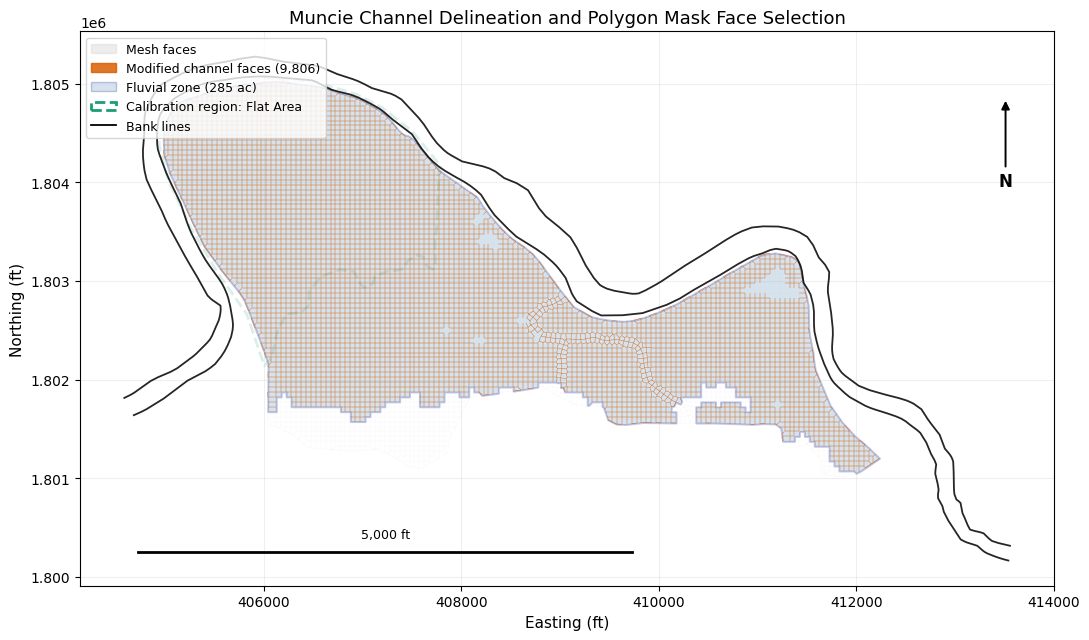

In [13]:

# --- Figure: Channel polygon, calibration region, and modified face locations ---
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Polygon, MultiPolygon

fig, ax = plt.subplots(figsize=(11, 7))

def polygon_patches(geom):
    geoms = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    patches = []
    for part in geoms:
        if isinstance(part, Polygon):
            coords = np.array(part.exterior.coords)
            patches.append(MplPolygon(coords[:, :2], closed=True))
    return patches

# Base mesh context and modified faces.
faces_gdf.plot(ax=ax, color='0.80', linewidth=0.15, alpha=0.35, label='Mesh faces')
channel_faces_gdf = faces_gdf[faces_gdf['face_id'].isin(channel_face_ids)]
channel_faces_gdf.plot(ax=ax, color='#d95f02', linewidth=0.35, alpha=0.85, label='Modified channel faces')

fluvial_patches = polygon_patches(fluvial_polygon)
ax.add_collection(PatchCollection(
    fluvial_patches, alpha=0.22, facecolor='steelblue', edgecolor='navy', linewidth=1.4,
))

calibration_patches = polygon_patches(calibration_polygon)
ax.add_collection(PatchCollection(
    calibration_patches, alpha=0.16, facecolor='none', edgecolor='#1b9e77',
    linewidth=2.0, linestyle='--',
))

for _, row in bank_lines.iterrows():
    coords = np.array(row.geometry.coords)
    ax.plot(coords[:, 0], coords[:, 1], color='black', linewidth=1.3, alpha=0.85)

legend_elements = [
    mpatches.Patch(facecolor='0.80', edgecolor='0.80', alpha=0.35, label='Mesh faces'),
    mpatches.Patch(facecolor='#d95f02', edgecolor='#d95f02', alpha=0.85,
                   label=f'Modified channel faces ({len(channel_face_ids):,})'),
    mpatches.Patch(facecolor='steelblue', edgecolor='navy', alpha=0.22,
                   label=f'Fluvial zone ({fluvial_acres:.0f} ac)'),
    mpatches.Patch(facecolor='none', edgecolor='#1b9e77', linestyle='--', linewidth=2,
                   label=f'Calibration region: {CALIBRATION_REGION_NAME}'),
]
legend_elements.append(Line2D([0], [0], color='black', linewidth=1.3, label='Bank lines'))
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')

ax.set_xlabel('Easting (ft)', fontsize=11)
ax.set_ylabel('Northing (ft)', fontsize=11)
ax.set_title('Muncie Channel Delineation and Polygon Mask Face Selection', fontsize=13)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

# North arrow and 5,000 ft scale bar.
ax.annotate('N', xy=(0.95, 0.88), xytext=(0.95, 0.73),
            xycoords='axes fraction', textcoords='axes fraction',
            ha='center', va='center', fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.4))
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
scale_len = 5000
x0 = xmin + 0.06 * (xmax - xmin)
y0 = ymin + 0.06 * (ymax - ymin)
ax.plot([x0, x0 + scale_len], [y0, y0], color='black', linewidth=2)
ax.text(x0 + scale_len / 2, y0 + 0.02 * (ymax - ymin), f'{scale_len:,.0f} ft',
        ha='center', va='bottom', fontsize=9)

fig.tight_layout()
plt.show()


## Step 8: Apply Depth-Varying n to Channel Faces Only

This secondary example demonstrates the polygon mask API on a fresh project
copy. Existing rows are transformed and the face tables are extended with
depth-varying Manning's n **only for channel faces** identified by the
fluvial polygon. Overbank faces retain their original uniform roughness and
table length.

Both guarded calls use the canonical `polygon=` filter.


In [14]:
# Re-extract a fresh modified project for the selective demo.
selective_path = RasExamples.extract_project(
    PROJECT_NAME, output_path=PROJECT_DIR, suffix="414_selective"
)
selective_ras = init_ras_project(
    selective_path, RAS_VERSION, ras_object="new", accept_tcu=True
)

# Preprocess only; then edit the selective .tmp.hdf without running the solver.
print("Preprocessing selective model to create a fresh .tmp.hdf...")
selective_preprocess = RasPreprocess.preprocess_plan(
    PLAN_NUMBER,
    ras_object=selective_ras,
    max_wait=300,
    clear_existing=True,
)
assert selective_preprocess.success, selective_preprocess.error
selective_tmp_hdf = Path(selective_preprocess.tmp_hdf_path)
assert selective_tmp_hdf.exists(), f"Missing selective tmp HDF: {selective_tmp_hdf}"

# Read original tables for comparison.
before_tables = HdfMesh.get_mesh_face_property_tables(selective_tmp_hdf)
before_df = before_tables[MESH_NAME]

# Transform existing rows and extend ONLY channel faces.
selective_transform_report = HdfMesh.transform_linux_tmp_face_mannings_n(
    hdf_path=selective_tmp_hdf,
    mesh_name=MESH_NAME,
    mannings_n_func=vegetal_retardance,
    polygon=fluvial_polygon,
    pin_tables=False,
    acknowledge_unsupported=True,
)
selective_transform_backup = Path(
    selective_transform_report["backup_path"]
)
assert selective_transform_report["faces_modified"] > 0
assert selective_transform_backup.exists()

selective_report = HdfMesh.extend_linux_tmp_face_property_tables(
    hdf_path=selective_tmp_hdf,
    mesh_name=MESH_NAME,
    extension_elevation=target_elev,
    mannings_n_func=depth_varying_extension_n,
    elevation_step=0.5,
    polygon=fluvial_polygon,   # Spatial filter from the polygon mask API.
    pin_tables=False,
    acknowledge_unsupported=True,
)
rows_added = selective_report["rows_added"]
selective_backup = Path(selective_report["backup_path"])

print(f"\nExtended {selective_report['faces_modified']} channel faces "
      f"(of {before_df['Face ID'].nunique()} total)")
print(
    f"Total rows added: {selective_report['total_rows_added']}; "
    f"backup={selective_backup.name}"
)
assert rows_added, "Expected channel faces to be extended"
assert selective_backup.exists(), "Expected a full-file selective-edit backup"
assert selective_backup not in {
    transform_backup, extension_backup, pinned_backup,
    selective_transform_backup,
}
assert selective_backup != selective_transform_backup
assert set(rows_added).issubset(set(channel_face_ids)), "Extended faces should come from polygon mask"

# Read back to verify.
after_selective = HdfMesh.get_mesh_face_property_tables(selective_tmp_hdf)
after_sel_df = after_selective[MESH_NAME]

# Compare row counts: channel faces should have more rows, overbank unchanged.
channel_set = set(rows_added.keys())
overbank_set = set(before_df['Face ID'].unique()) - channel_set
assert overbank_set, "Expected overbank faces to remain unmodified"

# Pick representative channel/overbank faces with the richest available tables.
channel_face_example = int(pd.Series(rows_added).sort_values(ascending=False).index[0])
overbank_counts = before_df[before_df['Face ID'].isin(overbank_set)].groupby('Face ID').size()
overbank_face_example = int(overbank_counts.sort_values(ascending=False).index[0])

ch_before = before_df[before_df['Face ID'] == channel_face_example]
ch_after = after_sel_df[after_sel_df['Face ID'] == channel_face_example]
print(f"\nChannel face {channel_face_example}: {len(ch_before)} -> {len(ch_after)} rows")
assert len(ch_after) > len(ch_before), "Channel face should be extended"
assert not np.allclose(
    ch_after[n_col].iloc[:len(ch_before)].to_numpy(),
    ch_before[n_col].to_numpy(),
), "Existing channel rows should receive depth-varying n"

ob_before = before_df[before_df['Face ID'] == overbank_face_example]
ob_after = after_sel_df[after_sel_df['Face ID'] == overbank_face_example]
print(f"Overbank face {overbank_face_example}: {len(ob_before)} -> {len(ob_after)} rows (unchanged)")
assert len(ob_after) == len(ob_before), "Overbank face should remain unchanged"
assert np.allclose(ob_after[n_col].to_numpy(), ob_before[n_col].to_numpy())


Preprocessing selective model to create a fresh .tmp.hdf...



Extended 9806 channel faces (of 11164 total)
Total rows added: 407361; backup=Muncie.p04.tmp.pre-write.20260725T191720490131Z.bak.hdf



Channel face 3041: 3 -> 69 rows
Overbank face 1156: 18 -> 18 rows (unchanged)


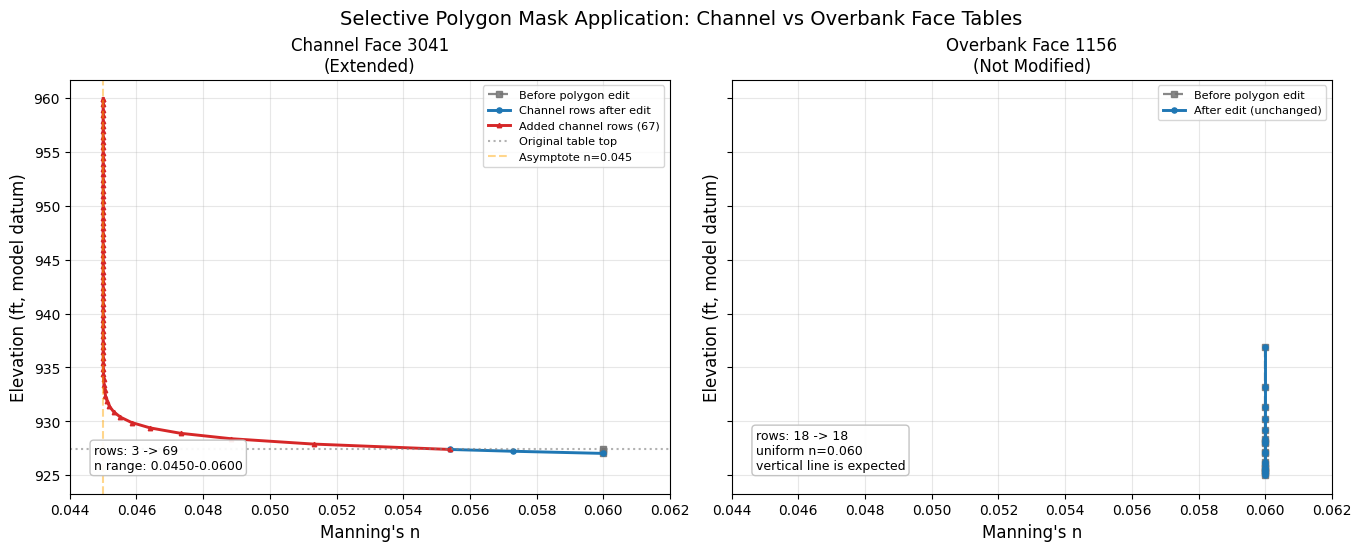

In [15]:

# --- Figure: Channel face (extended) vs Overbank face (unchanged) ---
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True, constrained_layout=True)
selective_xlim = (
    min(float(ch_after[n_col].min()), float(ob_after[n_col].min()), N_ASYMPTOTE) - 0.001,
    max(float(ch_after[n_col].max()), float(ob_after[n_col].max()), original_n) + 0.002,
)

# Channel face: extended with depth-varying n.
ax = axes[0]
ch_orig_max = ch_before['Elevation'].max()
ch_orig = ch_after[ch_after['Elevation'] <= ch_orig_max + 0.01]
ch_ext = ch_after[ch_after['Elevation'] > ch_orig_max - 0.01]

ax.plot(ch_before[n_col], ch_before['Elevation'], color='0.45', linestyle='--', marker='s',
        markersize=4, label='Before polygon edit', linewidth=1.6, alpha=0.85)
ax.plot(ch_orig[n_col], ch_orig['Elevation'], color='#1f77b4', marker='o', markersize=3.7,
        label='Channel rows after edit', linewidth=2.1)
ax.plot(ch_ext[n_col], ch_ext['Elevation'], color='#d62728', marker='^', markersize=3.2,
        label=f'Added channel rows ({len(ch_ext)})', linewidth=2.1)
ax.axhline(y=ch_orig_max, color='gray', linestyle=':', alpha=0.6, label='Original table top')
ax.axvline(x=N_ASYMPTOTE, color='orange', linestyle='--', alpha=0.45, label=f'Asymptote n={N_ASYMPTOTE:.3f}')
ax.set_xlim(*selective_xlim)
ax.set_xlabel("Manning's n", fontsize=12)
ax.set_ylabel('Elevation (ft, model datum)', fontsize=12)
ax.set_title(f'Channel Face {channel_face_example}\n(Extended)', fontsize=12)
ax.text(
    0.04, 0.06,
    f"rows: {len(ch_before)} -> {len(ch_after)}\n"
    f"n range: {ch_after[n_col].min():.4f}-{ch_after[n_col].max():.4f}",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='0.75', alpha=0.92),
)
ax.legend(fontsize=8.1, loc='upper right')
ax.grid(True, alpha=0.3)

# Overbank face: unchanged.
ax = axes[1]
ob_data = ob_after
ax.plot(ob_before[n_col], ob_before['Elevation'], color='0.45', linestyle='--', marker='s',
        markersize=4, label='Before polygon edit', linewidth=1.6, alpha=0.85)
ax.plot(ob_data[n_col], ob_data['Elevation'], color='#1f77b4', marker='o', markersize=3.7,
        label='After edit (unchanged)', linewidth=2.1)
ax.set_xlim(*selective_xlim)
ax.set_xlabel("Manning's n", fontsize=12)
ax.set_ylabel('Elevation (ft, model datum)', fontsize=12)
ax.set_title(f'Overbank Face {overbank_face_example}\n(Not Modified)', fontsize=12)
ax.text(
    0.04, 0.06,
    f"rows: {len(ob_before)} -> {len(ob_after)}\n"
    f"uniform n={ob_after[n_col].iloc[0]:.3f}\n"
    "vertical line is expected",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='0.75', alpha=0.92),
)
ax.legend(fontsize=8.1, loc='upper right')
ax.grid(True, alpha=0.3)

fig.suptitle('Selective Polygon Mask Application: Channel vs Overbank Face Tables', fontsize=14)
plt.show()


## Summary

This notebook demonstrated a controlled workflow for depth-varying Manning's
n in a coupled HEC-RAS 1D/2D model.

### What We Showed

1. **Model context**: Terrain, 61 White River cross sections, two lateral
   structures, a 5,391-cell 2D area, the 13,500–21,000 cfs upstream
   hydrograph, and the downstream 0.00064 normal-depth slope
2. **Three scenarios**: Baseline, extension-only control, and depth-varying n
3. **Controlled tables**: The control and modified cases used identical
   Elevation, Area, and Wetted Perimeter tables; n was the only difference
4. **Two-phase solver workflow**: Windows preprocessing followed by guarded
   temporary-HDF edits and native HEC-RAS 7.0 Linux solves
5. **Qualified execution**: All three solves finished successfully, reported
   their volume-accounting errors, and identified the exact runtime build
6. **Isolated hydraulic effect**: Modified minus extension-only-control WSE
   isolates the response to depth-varying n
7. **Extension evidence**: Control minus baseline separately quantifies the
   table-extension effect rather than assuming it is neutral
8. **Selective application**: Executed the canonical guarded `polygon=`
   workflow for channel-only calibration; the notebook reads a named
   calibration region but does not execute a guarded `region_name=` write

### Key Architecture Points

| Workflow | Method |
|----------|--------|
| Generate solver input tables | `RasPreprocess.preprocess_plan()` |
| Guarded solver-input n transform | `HdfMesh.transform_linux_tmp_face_mannings_n(tmp_hdf, ..., acknowledge_unsupported=True)` |
| Guarded table extension | `HdfMesh.extend_linux_tmp_face_property_tables(tmp_hdf, ..., acknowledge_unsupported=True)` |
| Consume edited tables | `RasCmdr.compute_plan_linux()` with the edited `.tmp.hdf` |
| Verify solver completion and volume error | `HdfResultsPlan.get_unsteady_summary()` and `get_volume_accounting()` |
| Informational metadata only | `HdfMesh.set_mesh_pinned_attribute()`; does not protect tables |
| Spatial filtering shown here | Executed `polygon=`; discovered a named calibration region with reader APIs |
| Channel identification | Calibration regions, fluvial/pluvial, bank lines, NFHL/GIS polygons |

### Adapting for Your Project

```python
ras = init_ras_project(
    "/path/to/your/project", "7.0", accept_tcu=True
)
result = RasPreprocess.preprocess_plan("01", ras_object=ras)
tmp_hdf = result.tmp_hdf_path

report = HdfMesh.extend_linux_tmp_face_property_tables(
    hdf_path=tmp_hdf,
    mesh_name="Your 2D Area",
    extension_elevation=960.0,
    mannings_n_func=my_n_func,
    region_name="Channel",
    pin_tables=False,
    acknowledge_unsupported=True,
)
assert Path(report["backup_path"]).exists()

RasCmdr.compute_plan_linux(
    "01",
    ras_exe_dir="/mnt/c/Program Files (x86)/HEC/HEC-RAS/7.0/Linux",
    ras_object=ras,
)
```

### References

- Chow, V.T., 1959. *Open-Channel Hydraulics*. McGraw-Hill.
- FHWA, 2005. *Design of Roadside Channels with Flexible Linings* (HEC-15). FHWA-NHI-05-114.
- Limerinos, J.T., 1970. USGS Water-Supply Paper 1898-B.
- Jarrett, R.D., 1984. *J. Hydraulic Engineering*, ASCE, 110(11): 1519-1539.
- [HEC-RAS Technical Reference — Energy Loss Coefficients](https://www.hec.usace.army.mil/confluence/rasdocs/ras1dtechref/6.6/basic-data-requirements/geometric-data/energy-loss-coefficients)
- [HEC-RAS 2D — Face Property Tables](https://www.hec.usace.army.mil/confluence/rasdocs/r2dum/latest/development-of-a-2d-or-combined-1d-2d-model/creating-hydraulic-property-tables-for-2d-flow-areas)
